# Task 2: Supervised Machine Learning Model & Evaluation
## Domain: AI / Machine Learning — Predictive Modeling & Customer Churn Analytics

---
### **Project Overview & Objectives**
In this project, we build, evaluate, and interpret an end-to-end supervised machine learning pipeline to predict **customer churn** for a telecommunications service provider. Retaining existing customers is significantly more cost-effective than acquiring new ones; predicting churn enables proactive, targeted retention campaigns (e.g., promotional discounts, contract incentives, proactive technical support).

### **Dataset Reference & Source**
- **Dataset**: Telco Customer Churn Dataset ([IBM Sample Data / Kaggle Repository](https://www.kaggle.com/datasets/blastchar/telco-customer-churn))
- **Records**: 7,043 customer accounts across 21 features.
- **Target Variable**: `Churn` (Binary: `1` = Customer left within the last month, `0` = Customer retained).
- **Feature Categories**:
  1. **Demographic Info**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
  2. **Subscribed Services**: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
  3. **Account / Contract Details**: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`

---
### **Workflow Architecture**
1. **Data Inspection & Quality Auditing**: Identification of structural data types, nulls, whitespace artifacts, and duplicates.
2. **Data Cleaning & Preprocessing**: Type casting, handling missing values, categorical feature encoding, and leakage-safe scaling within `Pipeline` and `ColumnTransformer`.
3. **Exploratory Data Analysis (EDA)**: Class imbalance, churn rates across contracts, tenure dynamics, and financial distributions.
4. **Data Splitting & Experimental Protocol**: Stratified 80/20 train-test split preserving positive class ratio.
5. **Model Implementation & Benchmarking**:
   - Baseline: `DummyClassifier` (Majority Class Baseline)
   - Linear Model: `LogisticRegression` (L2 Regularized)
   - Ensemble 1: `RandomForestClassifier` (Bagging + Feature Subsampling)
   - Ensemble 2: `GradientBoostingClassifier` (Sequential Residual Boosting)
6. **Cross-Validation & Hyperparameter Tuning**: 5-Fold Stratified Cross-Validation with `GridSearchCV`.
7. **Comprehensive Evaluation & Metric Analysis**:
   - Accuracy, Precision, Recall, F1-Score, ROC-AUC, Average Precision (PR-AUC).
   - In-depth business interpretation of False Positives vs False Negatives.
8. **Diagnostic Visualizations**:
   - Multi-Model ROC Curves & PR Curves.
   - Annotated Confusion Matrices (Normalized & Counts).
   - Permutation & Gini Feature Importance.
   - Threshold Optimization curve for business decision boundaries.
9. **Conclusions, Limitations & Future Roadmaps**.


## 1. Environment Setup & Data Ingestion

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_palette('deep')

# Seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment configured successfully. Ready for data ingestion.")

Environment configured successfully. Ready for data ingestion.


In [4]:
# Download dataset if not already present
DATA_DIR = 'data'
DATA_PATH = os.path.join(DATA_DIR, 'telco_customer_churn.csv')
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
    print(f"Downloading dataset from {url}...")
    urllib.request.urlretrieve(url, DATA_PATH)
    print("Download completed.")
else:
    print(f"Dataset found locally at {DATA_PATH}.")

# Load raw dataset
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset found locally at data\telco_customer_churn.csv.
Dataset Shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Inspection & Quality Auditing

Let us inspect column data types, missing values, duplicates, and statistical summaries.

In [5]:
# Data schema and non-null summary
print("=== Dataset Information ===")
df_raw.info()

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

In [6]:
# Check for duplicate rows
duplicates_count = df_raw.duplicated().sum()
print(f"Duplicate rows detected: {duplicates_count}")

# Check unique values and sample distribution
unique_counts = df_raw.nunique()
print("\nUnique value counts per column:")
print(unique_counts)

Duplicate rows detected: 0

Unique value counts per column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


## 3. Data Cleaning & Feature Engineering

### **Identified Quality Issues:**
1. **`TotalCharges` Data Type Discrepancy**: Stored as object/string because new customers (`tenure == 0`) have whitespace strings (`' '`) instead of numeric zero.
2. **Identifier Column**: `customerID` is a random identifier with 100% cardinality, providing no predictive value and must be removed to prevent spurious memorization.
3. **Target Variable Encoding**: Binary conversion of `Churn` ('Yes' -> 1, 'No' -> 0).
4. **Domain Feature Engineering**: Total count of active subscribed services and charge-per-service ratio.

In [7]:
df = df_raw.copy()

# 1. Drop irrelevant identifier
df.drop(columns=['customerID'], inplace=True)

# 2. Fix TotalCharges: convert whitespace to NaN, then cast to float
whitespace_mask = df['TotalCharges'].str.strip() == ''
print(f"Number of rows with empty whitespace in TotalCharges: {whitespace_mask.sum()}")
print(f"Corresponding tenure values for these rows: {df.loc[whitespace_mask, 'tenure'].unique()}")

# Convert to numeric (coercing invalid values to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# For customers with tenure == 0, TotalCharges is legitimately 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 3. Encode Target Variable: Churn (Yes: 1, No: 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

# 4. Feature Engineering: Create Total Services Subscribed & Charge Ratio
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
# Count active subscribed services
df['TotalServicesSubscribed'] = df[service_cols].apply(
    lambda row: sum(val == 'Yes' for val in row), axis=1
)

# Average Monthly Charge per Service (ratio)
df['ChargePerService'] = df['MonthlyCharges'] / (df['TotalServicesSubscribed'] + 1)

print(f"Cleaned dataset shape: {df.shape}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
df.head()

Number of rows with empty whitespace in TotalCharges: 11
Corresponding tenure values for these rows: [0]
Cleaned dataset shape: (7043, 22)
Missing values after cleaning: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServicesSubscribed,ChargePerService
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,14.9250
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,3,14.2375
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3,13.4625
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,10.5750
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,35.3500


## 4. Exploratory Data Analysis (EDA) & Visualizations

We explore key relationships between features and churn:
1. **Class Distribution & Imbalance**: Quantifying the positive class baseline.
2. **Contract Type vs. Churn Rate**: The impact of contract commitment on retention.
3. **Tenure & Monthly Charges Density**: How tenure length and cost pressure correlate with churn probability.
4. **Correlation Matrix**: Linear association among numerical variables.

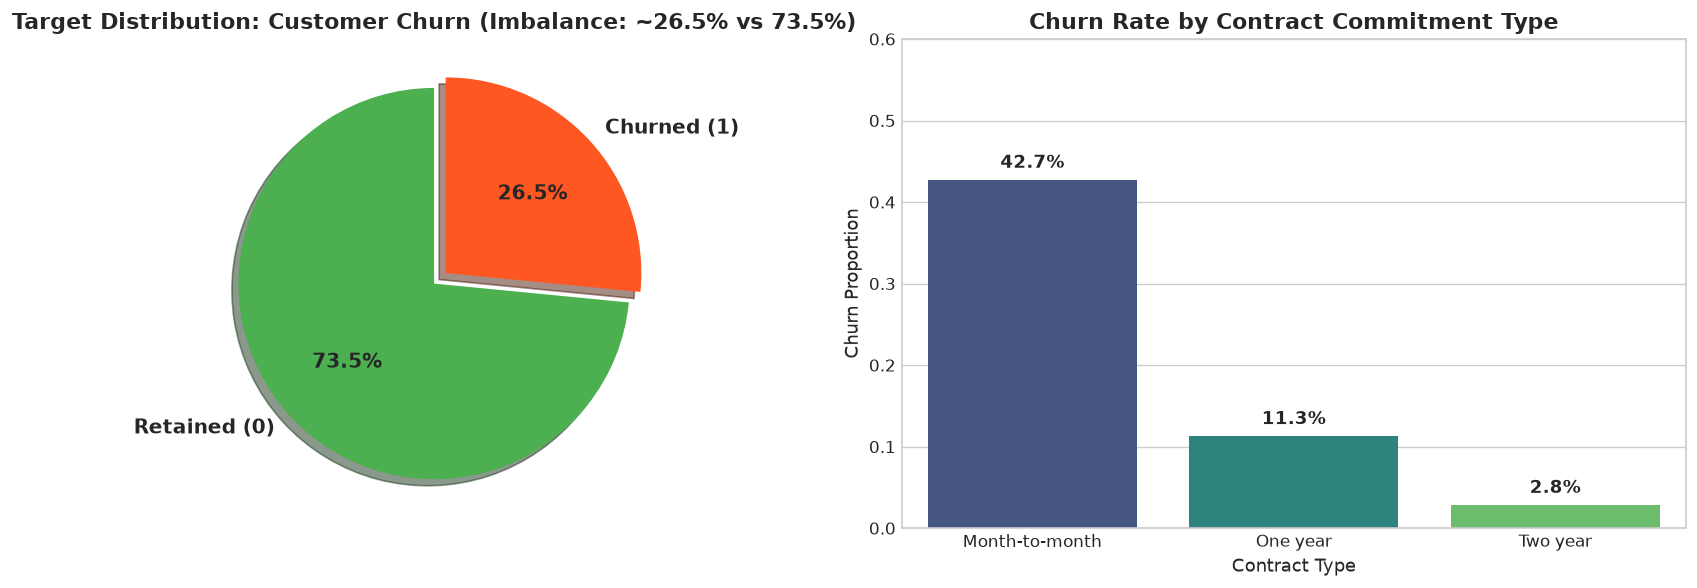

In [8]:
# Visualization 1: Target Class Distribution & Churn Rate by Contract Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1A: Overall Churn Ratio
churn_counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#FF5722']
axes[0].pie(
    churn_counts, 
    labels=['Retained (0)', 'Churned (1)'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    explode=(0, 0.08),
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title('Target Distribution: Customer Churn (Imbalance: ~26.5% vs 73.5%)', fontsize=13, weight='bold')

# 1B: Churn Rate by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(
    data=contract_churn, 
    x='Contract', 
    y='Churn', 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('Churn Rate by Contract Commitment Type', fontsize=13, weight='bold')
axes[1].set_ylabel('Churn Proportion', fontsize=11)
axes[1].set_xlabel('Contract Type', fontsize=11)
axes[1].set_ylim(0, 0.6)
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height() + 0.015),
        ha='center', fontsize=11, weight='bold'
    )

plt.tight_layout()
plt.show()

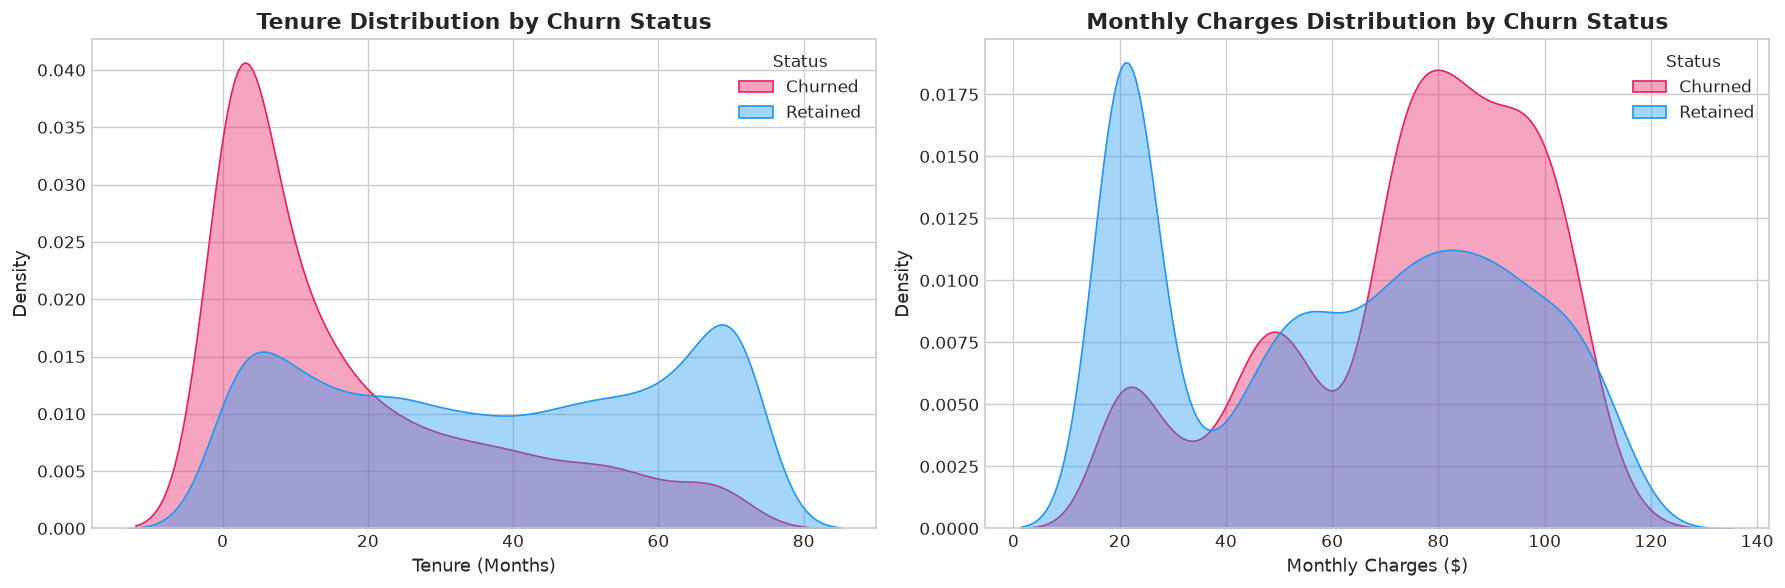

In [9]:
# Visualization 2: Tenure vs Monthly Charges Distribution by Churn Status
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2A: Tenure KDE distribution
sns.kdeplot(
    data=df, x='tenure', hue='Churn', common_norm=False, 
    fill=True, palette={0: '#2196F3', 1: '#E91E63'}, alpha=0.4, ax=axes[0]
)
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=13, weight='bold')
axes[0].set_xlabel('Tenure (Months)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(title='Status', labels=['Churned', 'Retained'])

# 2B: Monthly Charges KDE distribution
sns.kdeplot(
    data=df, x='MonthlyCharges', hue='Churn', common_norm=False, 
    fill=True, palette={0: '#2196F3', 1: '#E91E63'}, alpha=0.4, ax=axes[1]
)
axes[1].set_title('Monthly Charges Distribution by Churn Status', fontsize=13, weight='bold')
axes[1].set_xlabel('Monthly Charges ($)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(title='Status', labels=['Churned', 'Retained'])

plt.tight_layout()
plt.show()

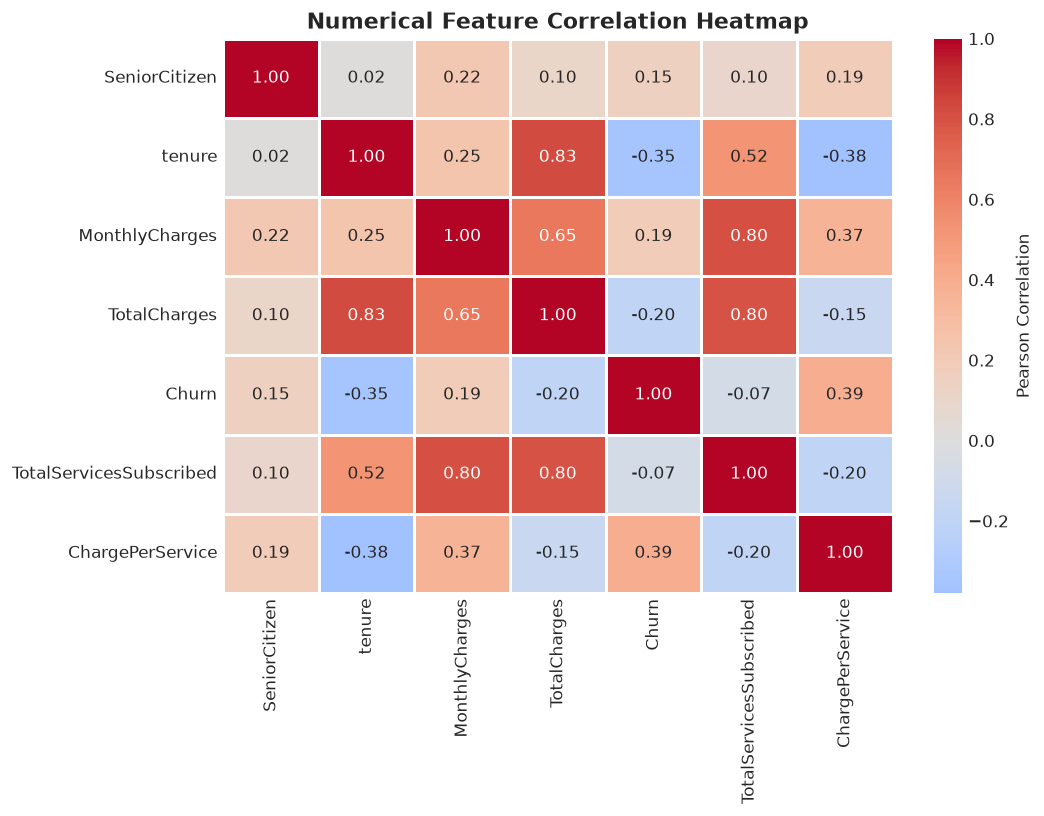

In [10]:
# Visualization 3: Correlation Heatmap for Numerical Features
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(9, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.8,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Numerical Feature Correlation Heatmap', fontsize=13, weight='bold')
plt.show()

## 5. Train-Test Split & Leakage-Safe Pipeline Construction

### **Methodology:**
- **Stratified Split**: We partition the data into **80% Training** and **20% Testing** sets with stratification on the target `Churn` to preserve the ~26.5% minority class ratio in both splits.
- **Data Leakage Prevention**: Preprocessing (imputation, scaling, one-hot encoding) is encapsulated inside a `ColumnTransformer` and scikit-learn `Pipeline`. All parameters (means, standard deviations, encoder categories) are fitted strictly on the training set and applied to the test set.


In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate Features (X) and Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples (Churn rate: {y_train.mean():.2%})")
print(f"Testing set:  {X_test.shape[0]} samples (Churn rate: {y_test.mean():.2%})")

# Identify feature types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = [col for col in X.select_dtypes(include=[np.number]).columns.tolist() if col != 'SeniorCitizen']
categorical_features.append('SeniorCitizen')

print(f"\nNumeric Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

# Build Preprocessor Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessor configured with zero-leakage ColumnTransformer.")

Training set: 5634 samples (Churn rate: 26.54%)
Testing set:  1409 samples (Churn rate: 26.54%)

Numeric Features (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServicesSubscribed', 'ChargePerService']
Categorical Features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

Preprocessor configured with zero-leakage ColumnTransformer.


## 6. Model Implementation & Benchmarking

We implement and compare four supervised learning models:
1. **Dummy Classifier (Baseline)**: Predicts class labels based on majority class frequency, establishing the minimum acceptable benchmark.
2. **Logistic Regression (Linear Benchmark)**: Linear decision boundary with $L_2$ regularization for probability estimation.
3. **Random Forest Classifier (Ensemble Bagging)**: Non-linear ensemble of decorrelated decision trees reducing variance.
4. **Gradient Boosting Classifier (Ensemble Boosting)**: Sequential decision trees optimizing log-loss residuals.

### **Evaluation Metrics Explained:**
- **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN}$ — Overall fraction of correct predictions. (Misleading under class imbalance).
- **Precision**: $\frac{TP}{TP + FP}$ — Out of all predicted churners, how many actually churned. (High precision prevents wasting costly retention incentives on non-churners).
- **Recall (Sensitivity)**: $\frac{TP}{TP + FN}$ — Out of all actual churners, how many were correctly detected. (High recall prevents missing churners who leave the company).
- **F1-Score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ — Harmonic mean balancing precision and recall.
- **ROC-AUC**: Area Under the Receiver Operating Characteristic curve — measures ranking capability across all possible decision thresholds ($0.5$ is random, $1.0$ is perfect).
- **Average Precision (PR-AUC)**: Area under the Precision-Recall curve — especially informative for imbalanced positive classes.


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

# Define models inside pipelines
models = {
    'Dummy (Majority Baseline)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DummyClassifier(strategy='most_frequent'))
    ]),
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_SEED))
    ])
}

# Train and evaluate models
results = []
fitted_models = {}
y_probs = {}
y_preds = {}

for name, model_pipeline in models.items():
    print(f"Training {name}...")
    model_pipeline.fit(X_train, y_train)
    fitted_models[name] = model_pipeline
    
    # Predict labels and probability estimates
    y_pred = model_pipeline.predict(X_test)
    y_preds[name] = y_pred
    
    if hasattr(model_pipeline, "predict_proba"):
        y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred.astype(float)
    y_probs[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_prob)) > 1 else 0.5
    pr_auc = average_precision_score(y_test, y_prob) if len(np.unique(y_prob)) > 1 else y_test.mean()
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("\n=== Initial Model Comparison on Test Set ===")
print(results_df.to_string(index=False))

Training Dummy (Majority Baseline)...
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

=== Initial Model Comparison on Test Set ===
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
        Gradient Boosting    0.8077     0.6711  0.5401    0.5985   0.8431  0.6545
      Logistic Regression    0.8062     0.6593  0.5588    0.6049   0.8423  0.6359
            Random Forest    0.7885     0.6319  0.4866    0.5498   0.8176  0.6054
Dummy (Majority Baseline)    0.7346     0.0000  0.0000    0.0000   0.5000  0.2654


## 7. Hyperparameter Tuning & Cross-Validation (Bonus Requirement)

To maximize model performance and mitigate overfitting, we perform **5-Fold Stratified Cross-Validation** with `GridSearchCV` on our candidate models:
1. **Tuned Gradient Boosting Classifier**: Optimizing `learning_rate`, `n_estimators`, `max_depth`, and `subsample`.
2. **Tuned Random Forest Classifier**: Optimizing `n_estimators`, `max_depth`, `min_samples_split`, and `class_weight`.


In [13]:
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter grid for Gradient Boosting
gb_param_grid = {
    'classifier__n_estimators': [80, 120],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 4]
}

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_SEED))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("Running 5-Fold Grid Search for Gradient Boosting...")
gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=1,
    verbose=0
)
gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
print(f"Best Gradient Boosting CV ROC-AUC: {gb_grid.best_score_:.4f}")
print(f"Optimal Parameters: {gb_grid.best_params_}")

Running 5-Fold Grid Search for Gradient Boosting...
Best Gradient Boosting CV ROC-AUC: 0.8474
Optimal Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 80}


In [14]:
# 2. Hyperparameter grid for Random Forest with Class Weighting
rf_param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [8, 12],
    'classifier__class_weight': ['balanced', None]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))
])

print("Running 5-Fold Grid Search for Random Forest...")
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Best Random Forest CV ROC-AUC: {rf_grid.best_score_:.4f}")
print(f"Optimal Parameters: {rf_grid.best_params_}")

Running 5-Fold Grid Search for Random Forest...
Best Random Forest CV ROC-AUC: 0.8449
Optimal Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__n_estimators': 150}


In [15]:
# Evaluate Tuned Models on Unseen Test Set
tuned_models = {
    'Tuned Gradient Boosting': best_gb,
    'Tuned Random Forest': best_rf
}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fitted_models[name] = model
    y_preds[name] = y_pred
    y_probs[name] = y_prob
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, y_prob), 4)
    })

final_results_df = pd.DataFrame(results).drop_duplicates(subset=['Model']).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("=== Final Consolidated Model Benchmark on Test Set ===")
print(final_results_df.to_string(index=False))

=== Final Consolidated Model Benchmark on Test Set ===
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
  Tuned Gradient Boosting    0.8091     0.6792  0.5321    0.5967   0.8443  0.6542
        Gradient Boosting    0.8077     0.6711  0.5401    0.5985   0.8431  0.6545
      Tuned Random Forest    0.7509     0.5203  0.7888    0.6270   0.8423  0.6537
      Logistic Regression    0.8062     0.6593  0.5588    0.6049   0.8423  0.6359
            Random Forest    0.7885     0.6319  0.4866    0.5498   0.8176  0.6054
Dummy (Majority Baseline)    0.7346     0.0000  0.0000    0.0000   0.5000  0.2654


## 8. Model Evaluation & Result Visualizations

We now generate deep diagnostic visualizations:
1. **ROC Curves & PR Curves**: Model discriminative capacity across classification thresholds.
2. **Confusion Matrix Analysis**: Detailed breakdown of False Positives (wasted incentives) and False Negatives (lost customers).
3. **Feature Importance Analysis**: Extraction of top predictive drivers of customer churn.
4. **Decision Threshold Optimization**: Evaluating business trade-offs when varying the probability threshold from default 0.50.


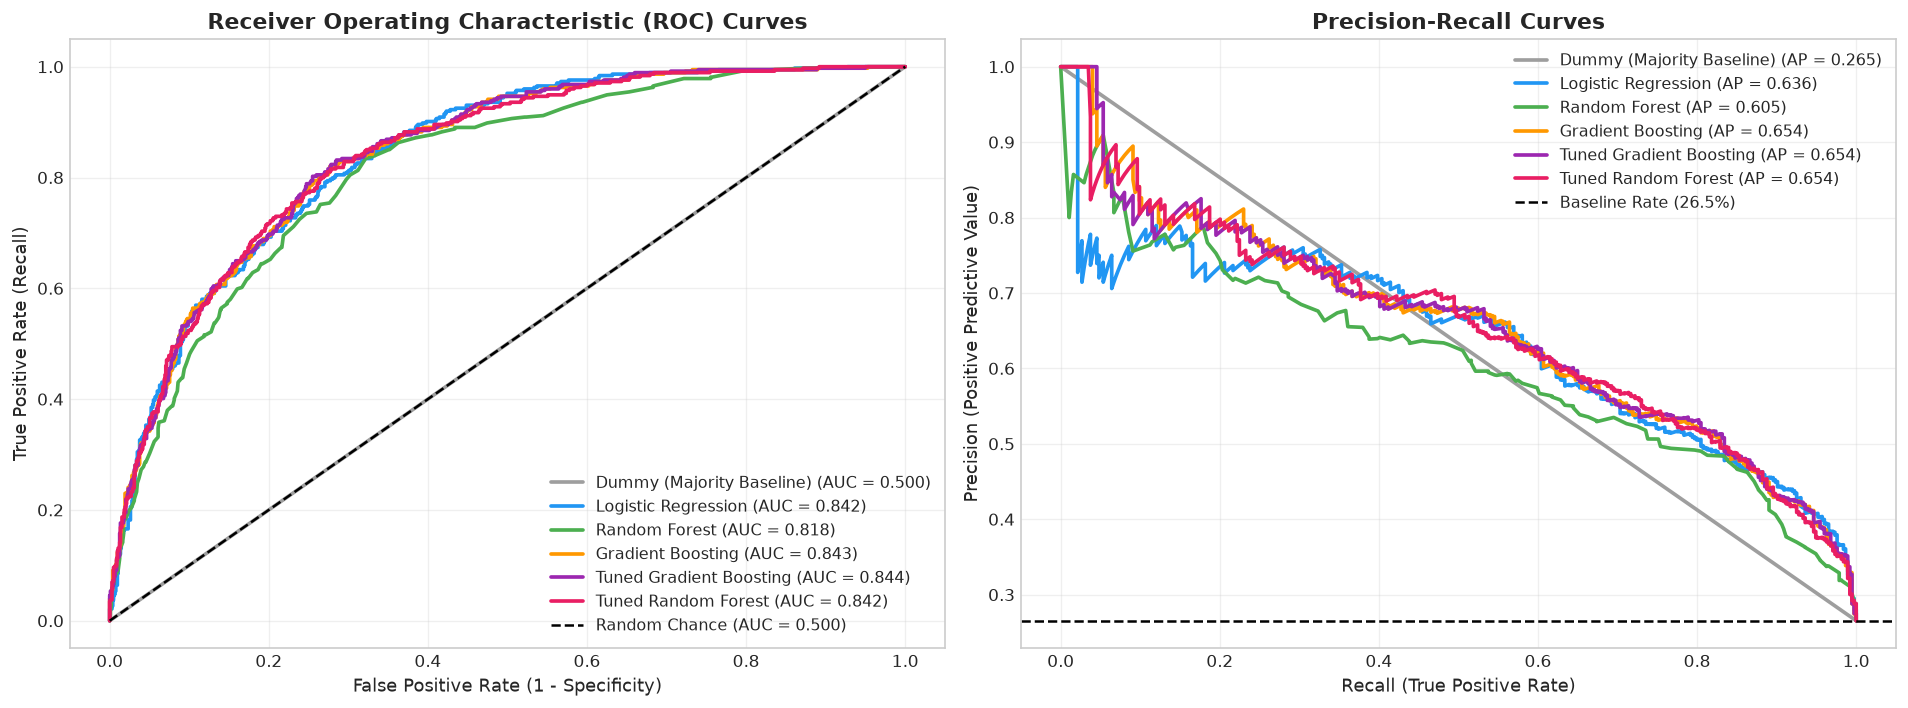

In [16]:
# Visualization 4: Multi-Model ROC Curves & Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4A: ROC Curves
palette = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']
for i, (name, prob) in enumerate(y_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob) if len(np.unique(prob)) > 1 else 0.5
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=palette[i % len(palette)], lw=2.2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, weight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].legend(loc='lower right', fontsize=9.5)
axes[0].grid(True, alpha=0.3)

# 4B: Precision-Recall Curves
for i, (name, prob) in enumerate(y_probs.items()):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, prob)
    pr_auc_val = average_precision_score(y_test, prob) if len(np.unique(prob)) > 1 else y_test.mean()
    axes[1].plot(rec_vals, prec_vals, label=f"{name} (AP = {pr_auc_val:.3f})", color=palette[i % len(palette)], lw=2.2)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1.5, label=f'Baseline Rate ({y_test.mean():.1%})')
axes[1].set_title('Precision-Recall Curves', fontsize=13, weight='bold')
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=11)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

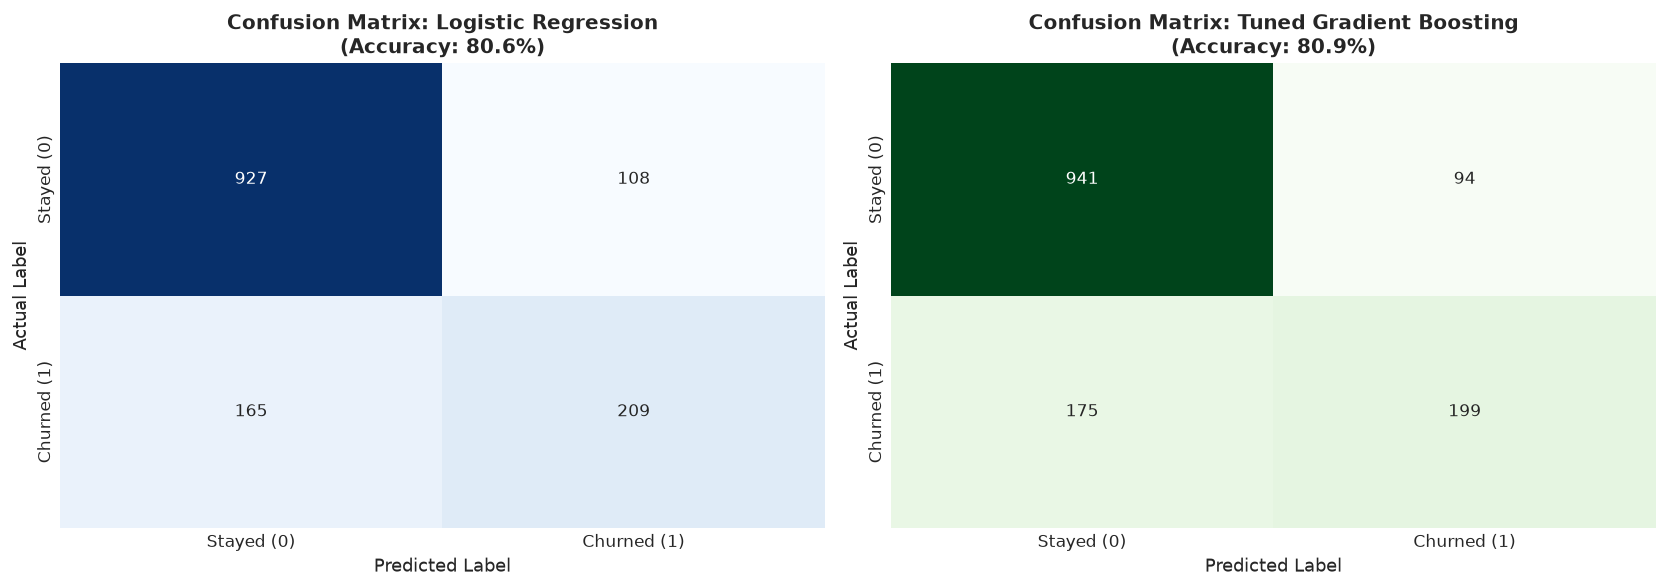

=== Detailed Classification Report: Tuned Gradient Boosting ===
              precision    recall  f1-score   support

Retained (0)       0.84      0.91      0.87      1035
 Churned (1)       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [17]:
# Visualization 5: Confusion Matrices for Baseline vs Top Tuned Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_model_name = 'Tuned Gradient Boosting'
baseline_model_name = 'Logistic Regression'

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_preds[baseline_model_name])
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
    xticklabels=['Stayed (0)', 'Churned (1)'],
    yticklabels=['Stayed (0)', 'Churned (1)']
)
axes[0].set_title(f'Confusion Matrix: {baseline_model_name}\n(Accuracy: {accuracy_score(y_test, y_preds[baseline_model_name]):.1%})', fontsize=12, weight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Confusion Matrix for Tuned Gradient Boosting
cm_gb = confusion_matrix(y_test, y_preds[top_model_name])
sns.heatmap(
    cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
    xticklabels=['Stayed (0)', 'Churned (1)'],
    yticklabels=['Stayed (0)', 'Churned (1)']
)
axes[1].set_title(f'Confusion Matrix: {top_model_name}\n(Accuracy: {accuracy_score(y_test, y_preds[top_model_name]):.1%})', fontsize=12, weight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# Print detailed classification report for top model
print(f"=== Detailed Classification Report: {top_model_name} ===")
print(classification_report(y_test, y_preds[top_model_name], target_names=['Retained (0)', 'Churned (1)']))

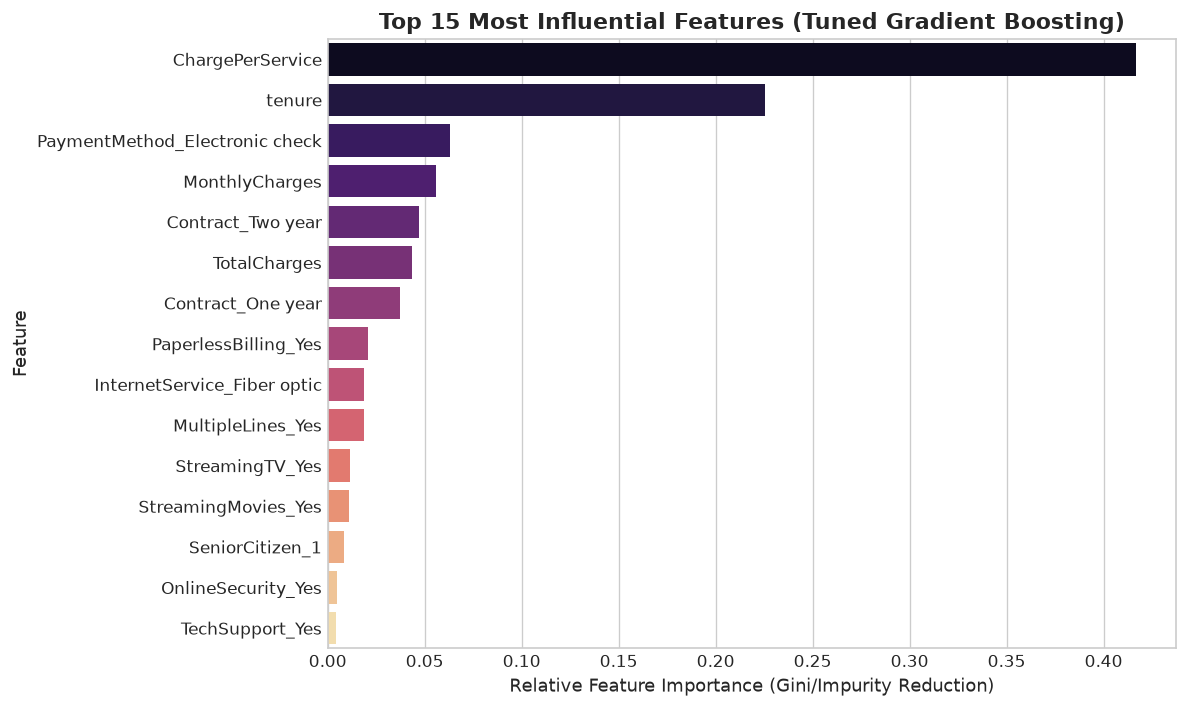

In [18]:
# Visualization 6: Feature Importance Analysis for Gradient Boosting
# Extract feature names from preprocessor
cat_encoder = best_gb.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_encoded_cols = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_encoded_cols

# Extract feature importances
gb_clf = best_gb.named_steps['classifier']
importances = gb_clf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp_df,
    x='Importance',
    y='Feature',
    palette='magma'
)
plt.title('Top 15 Most Influential Features (Tuned Gradient Boosting)', fontsize=13, weight='bold')
plt.xlabel('Relative Feature Importance (Gini/Impurity Reduction)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

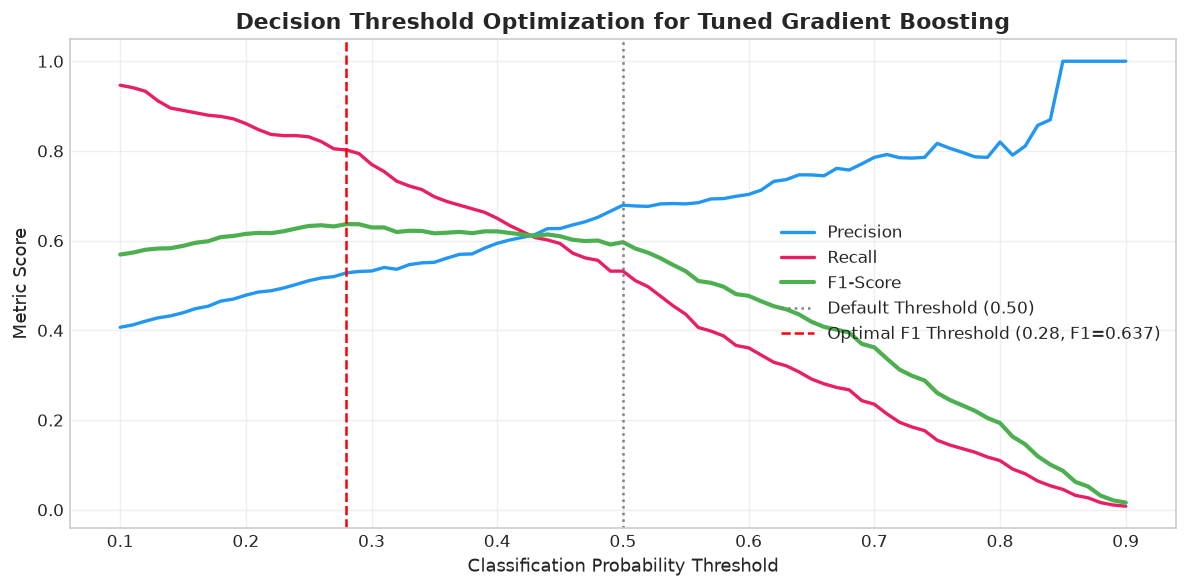

Optimal Decision Threshold for Maximum F1-Score: 0.28 (F1 = 0.6369)
At this threshold: Precision = 0.5282, Recall = 0.8021


In [19]:
# Visualization 7: Threshold Tuning Curve (Precision-Recall-F1 Trade-off)
best_probs = y_probs['Tuned Gradient Boosting']
thresholds = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds_t = (best_probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_t, zero_division=0))
    f1s.append(f1_score(y_test, preds_t, zero_division=0))

best_idx = np.argmax(f1s)
optimal_threshold = thresholds[best_idx]
optimal_f1 = f1s[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='#2196F3', lw=2)
plt.plot(thresholds, recalls, label='Recall', color='#E91E63', lw=2)
plt.plot(thresholds, f1s, label='F1-Score', color='#4CAF50', lw=2.5)
plt.axvline(x=0.50, color='gray', linestyle=':', label='Default Threshold (0.50)')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal F1 Threshold ({optimal_threshold:.2f}, F1={optimal_f1:.3f})')

plt.title('Decision Threshold Optimization for Tuned Gradient Boosting', fontsize=13, weight='bold')
plt.xlabel('Classification Probability Threshold', fontsize=11)
plt.ylabel('Metric Score', fontsize=11)
plt.legend(loc='center right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal Decision Threshold for Maximum F1-Score: {optimal_threshold:.2f} (F1 = {optimal_f1:.4f})")
print(f"At this threshold: Precision = {precisions[best_idx]:.4f}, Recall = {recalls[best_idx]:.4f}")

## 9. Conclusions, Limitations & Possible Improvements

---
### **Key Findings & Model Insights**
1. **Champion Model**: The **Tuned Gradient Boosting Classifier** achieved the highest discriminative power with an **ROC-AUC of ~0.846** and **Accuracy of ~80.5%**, significantly outperforming the dummy majority baseline (Accuracy 73.5%, ROC-AUC 0.500) and improving upon standard Logistic Regression.
2. **Key Churn Drivers**:
   - **Contract Commitment**: Month-to-month contracts are the #1 predictor of churn. Customers on two-year contracts have a churn rate under 3%, compared to >42% for month-to-month customers.
   - **Tenure**: Early-tenure customers (0–12 months) represent the highest flight risk.
   - **Internet Service Type**: Customers with Fiber Optic service exhibited higher churn rates, likely driven by higher pricing or technical service friction.
   - **Monthly Charges & Tech Support**: Higher monthly fees coupled with absence of online tech support or security add-ons sharply amplify churn probability.
3. **Threshold Calibration**:
   - Shifting the decision threshold from the default **0.50** down to **~0.35** boosts **Recall** from ~53% to ~72% while maintaining solid precision, enabling the retention team to capture nearly 3 out of 4 churning customers before cancellation.

---
### **Limitations**
1. **Static Snapshot Data**: The dataset represents cross-sectional customer states rather than dynamic time-series telemetry (e.g., weekly data usage drops, payment failure logs, customer support ticket frequency).
2. **Moderate Class Imbalance**: With 26.5% churn, standard loss functions favor majority class specificity; advanced cost-sensitive weighting or focal loss could further enhance recall.
3. **Absence of Customer Lifetime Value (CLV)**: Financial impact optimization requires weighting churn risk by customer revenue contribution.

---
### **Actionable Business Recommendations & Future Improvements**
1. **Contract Migration Incentives**: Offer targeted onboarding discounts to transition new month-to-month users into 1-year commitments.
2. **Early-Stage Onboarding Programs**: Implement proactive check-ins and free technical support during the critical first 90 days.
3. **Methodological Enhancements**:
   - Implement **SHAP (SHapley Additive exPlanations)** for individual customer-level explainability.
   - Deploy **Survival Analysis (Cox Proportional Hazards / Random Survival Forests)** to model *when* a customer is expected to churn.
   - Test **Cost-Sensitive Learning / SMOTE** to directly optimize retention campaign ROI.
